# Log-Odds CRP

> Baseline-correct temporal contiguity curves using log-odds transformation.

The log-odds CRP transforms standard conditional response probabilities into log-odds and subtracts a chosen reference lag to produce baseline-corrected contiguity curves. Positive values at a given lag indicate enrichment relative to the reference; negative values indicate suppression.

$$\text{logit}(p) = \log\!\left(\frac{p}{1-p}\right)$$

$$\Delta\text{LO}(\ell) = \text{logit}\bigl(\text{CRP}(\ell)\bigr) - \text{logit}\bigl(\text{CRP}(\ell_{\text{ref}})\bigr)$$

This representation is especially useful for lists with repeated items, where raw CRP values can be difficult to interpret due to varying availability.

## Workflow

In [1]:
import os
import matplotlib.pyplot as plt
import warnings
from jaxcmr.analyses.log_odds_crp import plot_log_odds_crp
from jaxcmr.helpers import find_project_root, generate_trial_mask, load_data, save_figure

warnings.filterwarnings("ignore")

In [2]:
data_path = "data/LohnasKahana2014.h5"
figure_dir = "results/figures"
figure_str = ""
ylim = None
trial_query = "data['list_type'] == 1"
max_lag = 5
reference_lag = 10
epsilon = 1e-6
size = 3
confidence_level = 0.95

In [3]:
project_root = find_project_root()
figure_dir = os.path.join(project_root, figure_dir)
data_path = os.path.join(project_root, data_path)
data = load_data(data_path)
trial_mask = generate_trial_mask(data, trial_query)

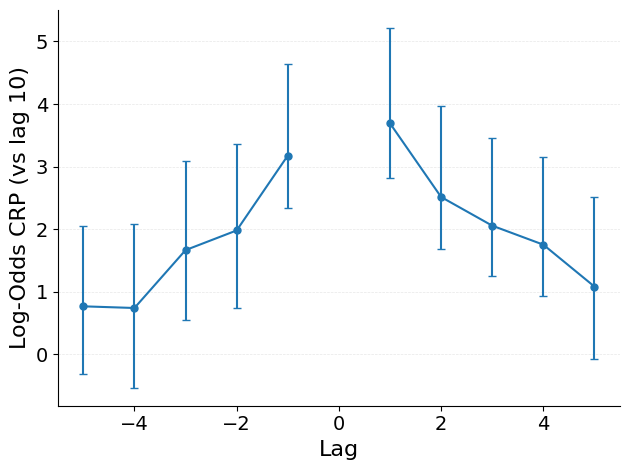

In [4]:
plot_log_odds_crp(
    data,
    trial_mask,
    max_lag=max_lag,
    reference_lag=reference_lag,
    epsilon=epsilon,
    size=size,
    confidence_level=confidence_level,
)
if ylim is not None:
    for ax in plt.gcf().axes:
        ax.set_ylim(ylim)
save_figure(figure_dir, figure_str)

## Interpretation

The x-axis shows serial lag and the y-axis shows log-odds relative to the reference lag. Key patterns:

- **Positive near ±1**: enrichment at short lags relative to the reference, indicating temporal contiguity.
- **Zero line**: the reference lag sits at zero by construction.
- **Advantage over raw CRP**: log-odds normalization makes curves comparable across conditions with different baseline transition rates.

## API Details

### Notebook parameters

- `data_path` — path to an HDF5 file containing a `RecallDataset`.
- `figure_dir` — directory for saving figures.
- `figure_str` — base filename for the saved figure. Leave empty to display without saving.
- `ylim` — y-axis limits as a tuple, or `None` for automatic scaling.
- `trial_query` — a Python expression evaluated against the dataset to select trials.
- `max_lag` — maximum lag to display on the x-axis.
- `reference_lag` — the lag used as the zero baseline for log-odds subtraction.
- `epsilon` — small constant clamping CRP values away from 0 and 1 to avoid infinite log-odds.
- `size` — maximum number of study positions a single item can occupy.
- `confidence_level` — confidence level for subject-wise error bars.